# CW1 - Multimodal IMDB Analysis with Keras

## Introduction

In this assignment you will be provided a dataset containing a selection of films together with their posters in JPEG image format and their overviews in text format from the Internet Movie Database.

![Example](https://i.ibb.co/J3trT62/Screenshot-2024-09-22-214753.png)

You will be analysing this dataset by implementing and training two models: a **CNN** and an **LSTM**.

The CNN must classify film posters by the genre. Independently, the LSTM must classify film overviews by the genre. Finally, you will evaluate and critically comment your results in a short report. (Which of the two models was better at classifying films?)

## Structure of the assignment

This assignment is broken up into sections and you need to complete each section successively. The sections are the following:

1. Data Processing

  1.a. Image processing of the posters

  1.b. Natural language processing of the overviews

2. Definition of the models

  2.a. CNN for the posters

  2.b. LSTM for the overviews

3. Training of the models
4. Evaluation of the models

In addition to this coding exercise, you must write a **2-3 pages** report analysing and critically evaluating your model's results. Marks for the report will be awarded for depth of analysis and critical thinking skills. You should consider how well your model performs and WHY it does that—give specific examples and comment on their importance.

In [1]:
# Enter your module imports here, some modules are already provided

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os
import pathlib
import pandas as pd
import random
from sklearn import model_selection
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.metrics import Precision, Recall
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Flatten, Dense
import random

In [2]:
# CodeGrade Tag Init1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Data Processing

Warning: running the following cell can take some time.


In [3]:
# CodeGrade Tag Init2
# Do not edit, remove, or copy this cell

# This code will copy the images from your google drive into the colab file
# storage. Make sure the dataset is unzipped in your drive folder.
! mkdir /tmp/Multimodal_IMDB_dataset
! rsync -ah --info=progress2 /content/drive/MyDrive/Multimodal_IMDB_dataset/Images /tmp/Multimodal_IMDB_dataset/


        191.65M 100%    1.16MB/s    0:02:36 (xfr#7896, to-chk=0/7897)


In [4]:
# CodeGrade Tag Init3
# Do not edit, remove, or copy this cell

# Load the csv with the sample IDs and genres
csv_loc = "/content/drive/MyDrive/Multimodal_IMDB_dataset/IMDB_overview_genres.csv"
dataset = pd.read_csv(csv_loc)

# Split the dataset into training and testing
data_train, data_test = model_selection.train_test_split(dataset, test_size=0.2)

# Convert the labels to arrays
labels_train = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')
labels_test = np.array(data_test.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')

# List of the genre names
genres = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1).columns)

# List of overviews
overviews_train = np.array(data_train['Overview'])
overviews_test = np.array(data_test['Overview'])

# Build the file locations for the images
img_loc = "/tmp/Multimodal_IMDB_dataset/Images"

img_locs_train = np.array([[img_loc + '/' + id + '.jpg' for id in data_train['Id']]])
img_locs_test = [[img_loc + '/' + id + '.jpg' for id in data_test['Id']]]

# This function is provided to read in the image files from the folder
def parse_image(filename, label):
  image = tf.io.read_file(filename)
  image = tf.io.decode_jpeg(image)
  return image, label


### 1.a. Image processing of the posters

In [5]:
# CodeGrade Tag Init4
# Do not edit, remove, or copy this cell

# Create the initial datasets of film posters
list_posters_train_ds = tf.data.Dataset.from_tensor_slices((img_locs_train[0], labels_train))
list_posters_valid_ds = tf.data.Dataset.from_tensor_slices((img_locs_test[0], labels_test))

* Create a function called ```img_process``` that converts the images to float32 datatype and resizes them to 64x64 pixels

In [6]:
# CodeGrade Tag Ex1a-i
### Create a function called img_process that converts the images to
### float32 datatype and resizes them to 64x64 pixels

def img_process(image, label):
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, [64, 64])
    return image, label

* **Using the ``tf.data`` API, load in the training and validation data for the posters. Be mindful of efficient data processing good practice to minimise the time it takes to load the data.**

In [7]:
# CodeGrade Tag Ex1a-ii
### Use the parse_image and img_process functions to construct the training and
### validation datasets. You should utilise good practice in optimising the
### dataset loading. Use a batch size of 64.

posters_train_ds = (list_posters_train_ds
                   .map(parse_image, num_parallel_calls = tf.data.AUTOTUNE)
                   .batch(64)
                   .map(img_process, num_parallel_calls = tf.data.AUTOTUNE)
                   .cache()
                   .prefetch(tf.data.AUTOTUNE))


posters_valid_ds = (list_posters_valid_ds
                   .map(parse_image, num_parallel_calls = tf.data.AUTOTUNE)
                   .batch(64)
                   .map(img_process, num_parallel_calls = tf.data.AUTOTUNE)
                   .cache()
                   .prefetch(tf.data.AUTOTUNE))

### 1.b. Natural Language processing of the overviews

In [8]:
# CodeGrade Tag Init5
# Do not edit, remove, or copy this cell

# Create the initial datasets of the film overviews
list_overviews_train_ds = tf.data.Dataset.from_tensor_slices((overviews_train, labels_train))
list_overviews_valid_ds = tf.data.Dataset.from_tensor_slices((overviews_test, labels_test))

* **Using the ``tf.data`` API, load in the training and validation data for the overviews.**

In [9]:
# CodeGrade Tag Ex1b-i
### Construct the training and validation datasets. Use a batch size of 64.

overviews_train_ds = (list_overviews_train_ds
                     .batch(64)
                     .prefetch(tf.data.AUTOTUNE))

overviews_valid_ds = (list_overviews_valid_ds
                     .batch(64)
                     .prefetch(tf.data.AUTOTUNE))

* Build the vocabulary of the model by calling the ``encoder.adapt()`` method on the film overviews train data.

In [10]:
# CodeGrade Tag Ex1b-ii
### Build the vocabulary of the model by calling the encoder.adapt() method on
### the film overviews train data.

VOCAB_SIZE = 10000

encoder = tf.keras.layers.TextVectorization(
    max_tokens = VOCAB_SIZE,
    output_mode = 'int'
)

encoder.adapt(overviews_train_ds.map(lambda text, label: text))

* Print the first 200 words of the vocabulary you obtained.

In [11]:
# CodeGrade Tag Ex1b-iii
### Print the first 200 words of the vocabulary you obtained.

vocab = encoder.get_vocabulary()

print("First 200 words in vocabulary:")
for i, word in enumerate(vocab[:200]):
    print(f"{i+1}: {word}")

First 200 words in vocabulary:
1: 
2: [UNK]
3: a
4: the
5: to
6: of
7: and
8: in
9: his
10: is
11: an
12: with
13: her
14: for
15: on
16: he
17: their
18: who
19: by
20: from
21: when
22: as
23: that
24: after
25: young
26: life
27: they
28: man
29: at
30: new
31: but
32: two
33: him
34: are
35: into
36: has
37: up
38: she
39: woman
40: one
41: love
42: out
43: family
44: find
45: be
46: finds
47: must
48: friends
49: it
50: school
51: story
52: them
53: world
54: about
55: while
56: group
57: where
58: have
59: girl
60: years
61: father
62: wife
63: home
64: get
65: town
66: back
67: help
68: city
69: three
70: lives
71: war
72: himself
73: during
74: becomes
75: all
76: son
77: gets
78: only
79: boy
80: york
81: murder
82: high
83: team
84: which
85: down
86: time
87: own
88: american
89: takes
90: mother
91: against
92: daughter
93: between
94: police
95: former
96: tries
97: other
98: can
99: small
100: its
101: falls
102: friend
103: before
104: being
105: become
106: will
107: ol

# 2. Definition of the models

### 2.a. CNN

**Using the Keras Functional API, create a convolutional neural network with the architecture shown in the model summary below.**

**A few important points to consider:**

* Call the convolutional layers and the first dense layer should have ReLU activation functions. The output layer should have a Sigmoid activation function.
* Pay attention to the output shapes and the number of partmeters for each layer, as these give indications as to the correct settings for the number of filters, kernel size, stride length and padding.
* Use the layer names provided in the summary in your model.
* For the dropout layers, use a dropout rate of 0.2 after the convolutional layers and 0.5 after the dense layers.


```
# Model Summary

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
=================================================================
 Input (InputLayer)          [(None, 64, 64, 3)]       0         
                                                                 
 Conv0 (Conv2D)              (None, 32, 32, 16)        448       
                                                                 
 Drop1 (Dropout)             (None, 32, 32, 16)        0         
                                                                 
 Conv1 (Conv2D)              (None, 32, 32, 32)        4640      
                                                                 
 Conv2 (Conv2D)              (None, 32, 32, 32)        9248      
                                                                 
 Drop2 (Dropout)             (None, 32, 32, 32)        0         
                                                                 
 Pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 Conv3 (Conv2D)              (None, 16, 16, 64)        18496     
                                                                 
 Conv4 (Conv2D)              (None, 16, 16, 64)        36928     
                                                                 
 Drop3 (Dropout)             (None, 16, 16, 64)        0         
                                                                 
 Pool2 (MaxPooling2D)        (None, 8, 8, 64)          0         
                                                                 
 Conv5 (Conv2D)              (None, 8, 8, 128)         73856     
                                                                 
 Conv6 (Conv2D)              (None, 8, 8, 128)         147584    
                                                                 
 Drop4 (Dropout)             (None, 8, 8, 128)         0         
                                                                 
 Pool3 (MaxPooling2D)        (None, 4, 4, 128)         0         
                                                                 
 Flat (Flatten)              (None, 2048)              0         
                                                                 
 FC1 (Dense)                 (None, 1024)              2098176   
                                                                 
 Drop5 (Dropout)             (None, 1024)              0         
                                                                 
 FC2 (Dense)                 (None, 1024)              1049600   
                                                                 
 Drop6 (Dropout)             (None, 1024)              0         
                                                                 
 Output (Dense)              (None, 25)                25625     
                                                                 
=================================================================
Total params: 3464601 (13.22 MB)
Trainable params: 3464601 (13.22 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


```



In [12]:
# CodeGrade Tag Ex2a-i
### Define the model using the Keras Functional API. Use the summary above as a
### guide for the model parameters. You will need to define the filters/units of
### the layers correctly, as well as the kernel size, stride length and padding
### of the convolutional layers.

def build_cnn_model():
    inputs = Input(shape = (64, 64, 3), name = 'Input')
    x = Conv2D(filters = 16, kernel_size = (3, 3), strides = 2, padding = 'same', activation = 'relu', name = 'Conv0')(inputs)
    x = Dropout(0.2, name = 'Drop1')(x)
    x = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'Conv1')(x)
    x = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'Conv2')(x)
    x = Dropout(0.2, name = 'Drop2')(x)
    x = MaxPooling2D(pool_size = (2, 2), name = 'Pool1')(x)
    x = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'Conv3')(x)
    x = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'Conv4')(x)
    x = Dropout(0.2, name = 'Drop3')(x)
    x = MaxPooling2D(pool_size = (2, 2), name = 'Pool2')(x)
    x = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'Conv5')(x)
    x = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'Conv6')(x)
    x = Dropout(0.2, name = 'Drop4')(x)
    x = MaxPooling2D(pool_size = (2, 2), name = 'Pool3')(x)
    x = Flatten(name = 'Flat')(x)
    x = Dense(1024, activation = 'relu', name = 'FC1')(x)
    x = Dropout(0.5, name = 'Drop5')(x)
    x = Dense(1024, activation = 'relu', name = 'FC2')(x)
    x = Dropout(0.5, name = 'Drop6')(x)
    outputs = Dense(25, activation = 'sigmoid', name = 'Output')(x)
    model = Model(inputs = inputs, outputs = outputs, name = 'model')
    return model

cnn_model = build_cnn_model()

* Print the model summary and confirm it has the same architecture as the one provided.

In [13]:
# CodeGrade Tag Ex2a-ii
### Print the model summary and confirm it has the same architecture as the one
### provided.

cnn_model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv0 (Conv2D)                  │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop1 (Dropout)                 │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop2 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop3 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv5 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv6 (Conv2D)                  │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop4 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flat (Flatten)                  │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop5 (Dropout)                 │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop6 (Dropout)                 │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 25)             │        25,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,464,601 (13.22 MB)

 Trainable params: 3,464,601 (13.22 MB)

 Non-trainable params: 0 (0.00 B)

* **Compile the model using the Adam Optimizer with a learning rate of ```1e-4``` and ```binary crossentropy``` loss function. For the metrics, use the ``Precision`` and ``Recall`` functions.**

In [14]:
# CodeGrade Tag Ex2a-iii
### Compile the model using the Adam Optimizer with a learning rate of 1e-4 and
### binary crossentropy loss function. For the metrics, use the Precision and
### Recall functions.

cnn_model.compile(
    optimizer = Adam(learning_rate = 1e-4),
    loss = 'binary_crossentropy',
    metrics = [Precision(), Recall()]
    )

### 2.b. LSTM model

* Set up the embedding layer by using ```tf.keras.layers.Embedding```. The ```input_dim``` is the length of the vocab, and the ```output_dim``` must be **265**. You should also set ```mask_zero=True```.

In [15]:
# CodeGrade Tag Ex2b-i
### Set up the embedding layer. The input_dim is the length of the vocab, and
### the output_dim must be 256. You should also set mask_zero=True.

embedder = tf.keras.layers.Embedding(
    input_dim = len(encoder.get_vocabulary()),
    output_dim = 256,
    mask_zero = True
)

* Use ```tf.keras.Sequential``` to build a keras sequential model, with the following layers:



  1.   encoder
  2.   embedder
  3.   biLSTM layer with 256 units, dropout 0.5, recurrent dropout 0.2 (make sure to use the right ```return_sequences``` parametre to be able to stack this layer with the following BiLSTM)
  4.   biLSTM layer with 128 units, dropout 0.5, recurrent dropout 0.2
  5.   dense layer with 128 units and relu activation function
  6.   dropout with rate 0.8
  7.   dense output layer with 25 units and sigmoid activation function



In [16]:
# CodeGrade Tag Ex2b-ii
### Build a keras sequential model, with the layers provided above.

lstm_model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim = len(encoder.get_vocabulary()),
        output_dim = 256,
        mask_zero = True
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences = True)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dense(25, activation = 'sigmoid')
])

lstm_model.build((None,))

* Print the model summary and confirm is has the same architecture as the outline provided above.

In [17]:
# CodeGrade Tag Ex2b-iii
### Print the model summary and confirm is has the same architecture as the
### outline provided above.

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 256)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 256)      │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,158,041 (12.05 MB)

 Trainable params: 3,158,041 (12.05 MB)

 Non-trainable params: 0 (0.00 B)

* Compile the model with binary crossentropy loss and the adam optimizer. For the metrics, use the Precision and Recall functions.

In [18]:
# CodeGrade Tag Ex2b-iv
### Compile the model with binary crossentropy loss, the adam optimizer, with
### the precision and recall metrics

lstm_model.compile(
    optimizer = Adam(learning_rate = 1e-4),
    loss = 'binary_crossentropy',
    metrics = [Precision(), Recall()]
    )

# 3. Training of the models

* **For each model, create a Checkpoint Callback that saves the weights of the best performing epoch, based on the validation loss.**

In [19]:
# CodeGrade Tag Ex3a-i
### Create two ModelCheckpoint callbacks to store the bext weights from each
### model, both based on the validation loss.

checkpoint_cnn_filepath = '/content/checkpoint_cnn.weights.h5'
checkpoint_lstm_filepath = '/content/checkpoint_lstm.weights.h5'

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cnn_callback = ModelCheckpoint(
    filepath = checkpoint_cnn_filepath,
    save_weights_only = True,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True
)

checkpoint_lstm_callback = ModelCheckpoint(
    filepath = checkpoint_lstm_filepath,
    save_weights_only = True,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True
)


* **Create a Learning Rate Scheduler Callback that utilises the provided function to decrease the learning rate during training.**

In [20]:
# CodeGrade Tag Ex3a-ii
### Using the function provided, create a LearningRateScheduler callback, call
### it "lr_callback"

def scheduler(epoch, lr):
    if epoch < 10:
        return float(lr)
    else:
        return float(lr * tf.math.exp(-0.01))

lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler)


### 3.a. CNN training

* **Train the CNN model for 40 epochs, using the callbacks you made previously. Store the losses and metrics to use later.**

In [21]:
# CodeGrade Tag Ex3a-iii
### Train the model for 40 epochs, using the callbacks you have created. Store
### the losses and metrics in a history object.

cnn_history = cnn_model.fit(
    posters_train_ds,
    validation_data = posters_valid_ds,
    epochs = 40,
    callbacks = [checkpoint_cnn_callback, lr_callback]
    )

Epoch 1/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 73s 850ms/step - loss: 0.4497 - precision: 0.2607 - recall: 0.2708 - val_loss: 0.3065 - val_precision: 0.4856 - val_recall: 0.4076 - learning_rate: 1.0000e-04
Epoch 2/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 66s 820ms/step - loss: 0.2548 - precision: 0.4850 - recall: 0.2220 - val_loss: 0.3021 - val_precision: 0.5377 - val_recall: 0.2506 - learning_rate: 1.0000e-04
Epoch 3/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 77s 768ms/step - loss: 0.2475 - precision: 0.5030 - recall: 0.2195 - val_loss: 0.2865 - val_precision: 0.5154 - val_recall: 0.2164 - learning_rate: 1.0000e-04
Epoch 4/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 771ms/step - loss: 0.2432 - precision: 0.5275 - recall: 0.2238 - val_loss: 0.2838 - val_precision: 0.5541 - val_recall: 0.3077 - learning_rate: 1.0000e-04
Epoch 5/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 61s 768ms/step - loss: 0.2368 - precision: 0.5453 - recall: 0.2591 - val_loss: 0.2803 - val_precision: 0.5574 - val_recall: 0.3043 - learning_rate: 1.0000e-04
Epoch 6/40
80/8

* **Train the model for 20 epochs** (this may take several minutes)**, using the callbacks you made previously. Store the losses and metrics to use later.**

In [22]:
# CodeGrade Tag Ex3b-i
# Train the model for 20 epochs.
lstm_history = lstm_model.fit(
     overviews_train_ds,
     validation_data = overviews_valid_ds,
     epochs = 20,
     callbacks = [checkpoint_lstm_callback, lr_callback]
                    )

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 61s 625ms/step - loss: 0.6614 - precision_1: 0.1375 - recall_1: 0.3469 - val_loss: 0.2716 - val_precision_1: 0.5154 - val_recall_1: 0.2164 - learning_rate: 1.0000e-04
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 76s 561ms/step - loss: 0.2606 - precision_1: 0.5276 - recall_1: 0.1874 - val_loss: 0.2400 - val_precision_1: 0.5154 - val_recall_1: 0.2164 - learning_rate: 1.0000e-04
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 47s 590ms/step - loss: 0.2473 - precision_1: 0.5117 - recall_1: 0.2063 - val_loss: 0.2389 - val_precision_1: 0.5154 - val_recall_1: 0.2164 - learning_rate: 1.0000e-04
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 46s 572ms/step - loss: 0.2441 - precision_1: 0.5132 - recall_1: 0.2104 - val_loss: 0.2382 - val_precision_1: 0.5154 - val_recall_1: 0.2164 - learning_rate: 1.0000e-04
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 80s 553ms/step - loss: 0.2437 - precision_1: 0.5051 - recall_1: 0.2087 - val_loss: 0.2378 - val_precision_1: 0.5154 - val_recall_1: 0.2164 - l

# 4. Evaluation of the models

### 4.a. CNN Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

Available metrics in CNN history: dict_keys(['loss', 'precision', 'recall', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])


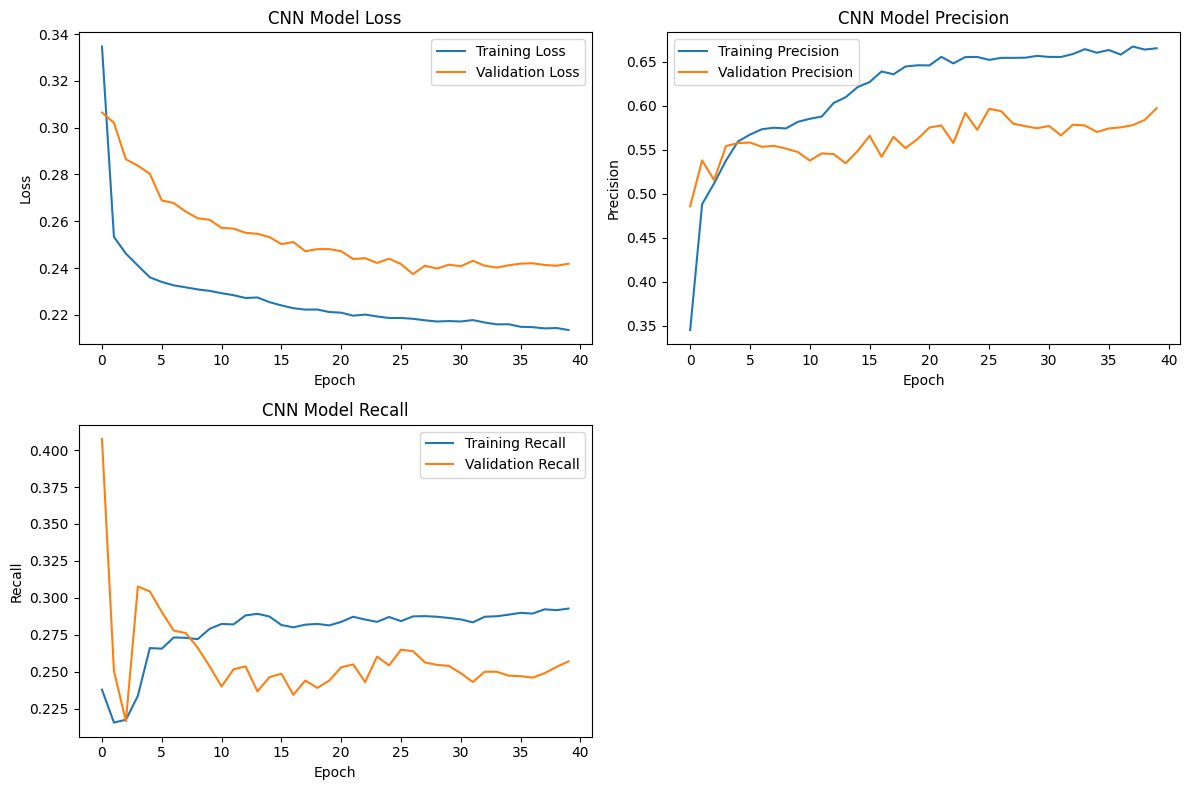

In [24]:
# CodeGrade Tag Ex4a-i

# Reproducibility
os.environ['PYTHONHASHSEED'] = '0'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Configure TensorFlow
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
if hasattr(tf, 'config'):
    tf.config.experimental.enable_op_determinism()

# Check available metrics in history
print("Available metrics in CNN history:", cnn_history.history.keys())

# Create the figure
plt.figure(figsize = (12, 8))

# Plot training & validation loss
plt.subplot(2, 2, 1)
plt.plot(cnn_history.history['loss'], label = 'Training Loss')
plt.plot(cnn_history.history['val_loss'], label = 'Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Find the correct keys for precision and recall
precision_key = next(k for k in cnn_history.history.keys()
                   if 'precision' in k.lower() and not k.startswith('val_'))
val_precision_key = next(k for k in cnn_history.history.keys()
                       if 'precision' in k.lower() and k.startswith('val_'))

recall_key = next(k for k in cnn_history.history.keys()
                if 'recall' in k.lower() and not k.startswith('val_'))
val_recall_key = next(k for k in cnn_history.history.keys()
                    if 'recall' in k.lower() and k.startswith('val_'))

# Plot training & validation precision
plt.subplot(2, 2, 2)
plt.plot(cnn_history.history[precision_key], label = 'Training Precision')
plt.plot(cnn_history.history[val_precision_key], label = 'Validation Precision')
plt.title('CNN Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

# Plot training & validation recall
plt.subplot(2, 2, 3)
plt.plot(cnn_history.history[recall_key], label = 'Training Recall')
plt.plot(cnn_history.history[val_recall_key], label = 'Validation Recall')
plt.title('CNN Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.savefig('cnn_model_performance.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Load the best weights from checkpoint
cnn_model.load_weights(checkpoint_cnn_filepath)

* **Load the best weights from your model checkpoint, and create plots demonstrating the classification performance for all three classes. Include these plots in your report, and critically evaluate on the performance of the model across the classes.**

### 4.b. LSTM Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

Available metrics in LSTM history: dict_keys(['loss', 'precision_1', 'recall_1', 'val_loss', 'val_precision_1', 'val_recall_1', 'learning_rate'])


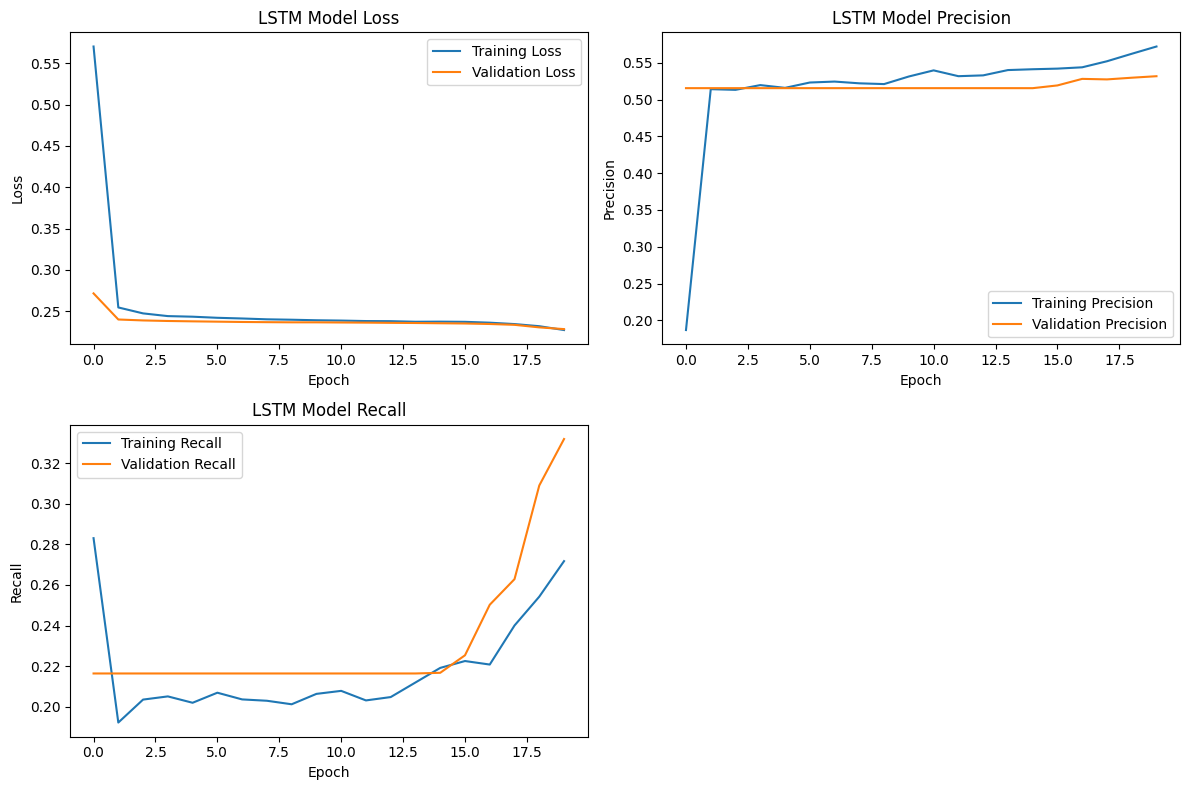

In [26]:
# CodeGrade Tag Ex4b-i

# Reproducibility
os.environ['PYTHONHASHSEED'] = '0'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Configure TensorFlow for deterministic operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
if hasattr(tf, 'config'):
    tf.config.experimental.enable_op_determinism()

# Check available metrics in history
print("Available metrics in LSTM history:", lstm_history.history.keys())

# Create the figure with fixed size
plt.figure(figsize = (12, 8))

# Plot training & validation loss
plt.subplot(2, 2, 1)
plt.plot(lstm_history.history['loss'], label = 'Training Loss')
plt.plot(lstm_history.history['val_loss'], label = 'Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Find the correct keys for precision and recall
lstm_precision_key = next(k for k in lstm_history.history.keys()
                         if 'precision' in k.lower() and not k.startswith('val_'))
lstm_val_precision_key = next(k for k in lstm_history.history.keys()
                             if 'precision' in k.lower() and k.startswith('val_'))

lstm_recall_key = next(k for k in lstm_history.history.keys()
                      if 'recall' in k.lower() and not k.startswith('val_'))
lstm_val_recall_key = next(k for k in lstm_history.history.keys()
                          if 'recall' in k.lower() and k.startswith('val_'))

# Plot training & validation precision
plt.subplot(2, 2, 2)
plt.plot(lstm_history.history[lstm_precision_key], label = 'Training Precision')
plt.plot(lstm_history.history[lstm_val_precision_key], label = 'Validation Precision')
plt.title('LSTM Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

# Plot training & validation recall
plt.subplot(2, 2, 3)
plt.plot(lstm_history.history[lstm_recall_key], label = 'Training Recall')
plt.plot(lstm_history.history[lstm_val_recall_key], label = 'Validation Recall')
plt.title('LSTM Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.savefig('lstm_model_performance.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Load the best weights from checkpoint
lstm_model.load_weights(checkpoint_lstm_filepath)

### 4.c. Produce examples for the report

* First, load the best weights from your checkpoints of both your models.

* Choose a few films from the dataset, plot their posters and print their overviews. Use these example films to demonstrate the classification performance of the CNN model on their posters and of the LSTM model on their overview.

* Be sure to demonstrate the results of the multi-label classification. Compare, for each example film, the top three most probable genres predicted by the CNN and the top three most probable genres predicted by the LSTM with the ground truth genres.

* Include these examples in your report, and critically evaluate on the performance of the model across the classes.


================================================== FILM ANALYSIS ==================================================



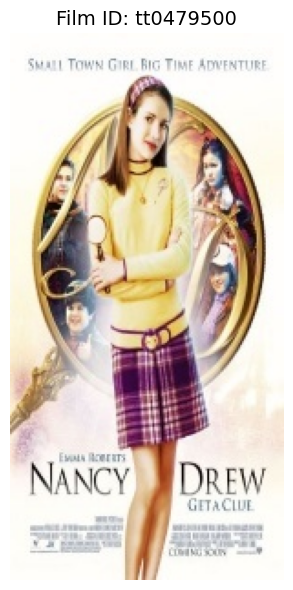


GROUND TRUTH GENRES: Comedy, Crime, Family

FILM OVERVIEW:
Teen detective Nancy Drew accompanies her father on a business trip to Los Angeles, where she happens upon clues to a murder mystery involving a movie star.


CNN (Poster) Predictions:
- Comedy: 0.6140 (ground truth: yes)
- Drama: 0.6022 (ground truth: no)
- Romance: 0.4348 (ground truth: no)

LSTM (Overview) Predictions:
- Comedy: 0.5969 (ground truth: yes)
- Drama: 0.5893 (ground truth: no)
- Romance: 0.3156 (ground truth: no)




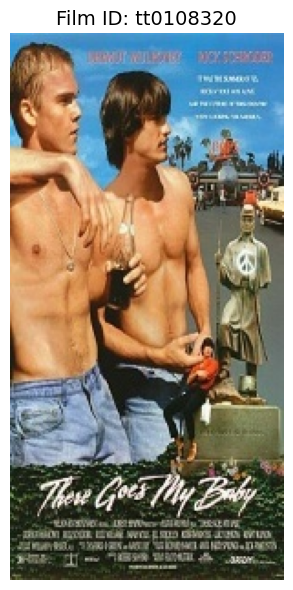


GROUND TRUTH GENRES: Comedy, Drama

FILM OVERVIEW:
Graduates of a Los Angeles high school in 1965 see America's culture and politics gradually change.


CNN (Poster) Predictions:
- Comedy: 0.5982 (ground truth: yes)
- Drama: 0.5388 (ground truth: yes)
- Romance: 0.3491 (ground truth: no)

LSTM (Overview) Predictions:
- Comedy: 0.5916 (ground truth: yes)
- Drama: 0.5808 (ground truth: yes)
- Romance: 0.3152 (ground truth: no)




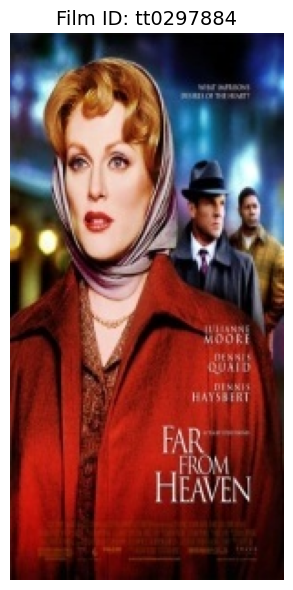


GROUND TRUTH GENRES: Drama, Romance

FILM OVERVIEW:
In 1950s Connecticut, a housewife faces a marital crisis and mounting racial tensions in the outside world.


CNN (Poster) Predictions:
- Drama: 0.5954 (ground truth: yes)
- Comedy: 0.3368 (ground truth: no)
- Action: 0.3325 (ground truth: no)

LSTM (Overview) Predictions:
- Drama: 0.6125 (ground truth: yes)
- Comedy: 0.5311 (ground truth: no)
- Romance: 0.2961 (ground truth: yes)


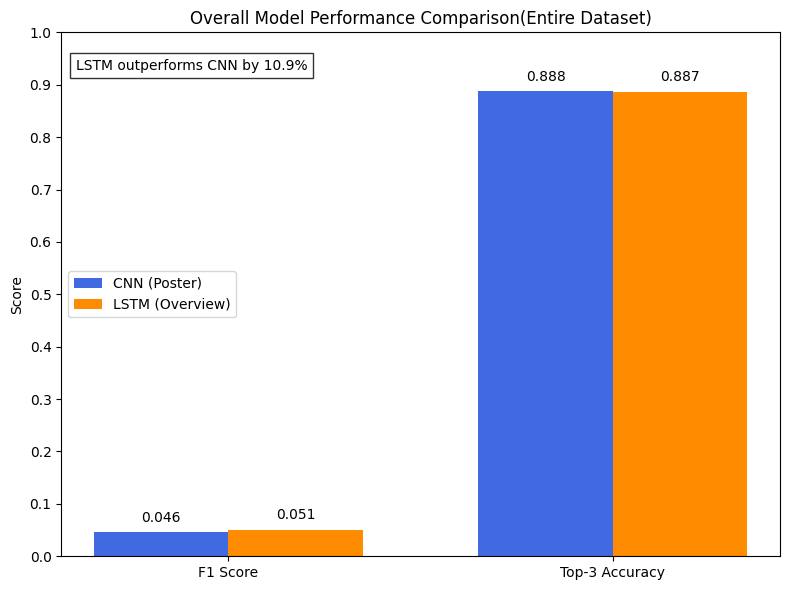

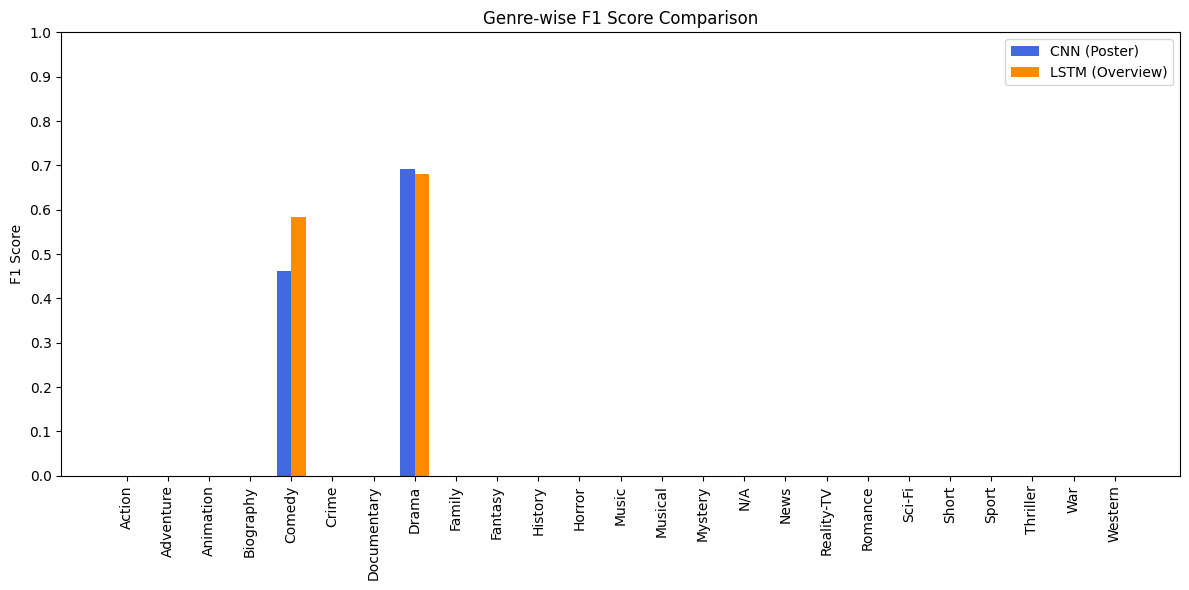

In [53]:
# CodeGrade Tag Ex4c

# Set all seeds for reproducibility
os.environ['PYTHONHASHSEED'] = '0'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Configure TensorFlow for deterministic operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
if hasattr(tf, 'config'):
    tf.config.experimental.enable_op_determinism()

# Load the best weights from both models
cnn_model.load_weights(checkpoint_cnn_filepath)
lstm_model.load_weights(checkpoint_lstm_filepath)

# Select 3 films from the test set
sample_indices = [23, 119, 91]
sample_films = data_test.iloc[sample_indices].reset_index(drop = True)

# Calculate predictions for the entire validation set
cnn_preds = cnn_model.predict(posters_valid_ds, verbose = 0)
lstm_preds = lstm_model.predict(overviews_valid_ds, verbose = 0)

# Function to calculate precision, recall, f1 for each genre
def calculate_genre_metrics(true_labels, preds, threshold = 0.5):
    metrics = []
    preds_binary = (preds > threshold).astype(int)

    for i, genre in enumerate(genres):
        true_pos = np.sum((true_labels[:, i] == 1) & (preds_binary[:, i] == 1))
        false_pos = np.sum((true_labels[:, i] == 0) & (preds_binary[:, i] == 1))
        false_neg = np.sum((true_labels[:, i] == 1) & (preds_binary[:, i] == 0))

        precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
        recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        metrics.append((genre, precision, recall, f1))

    return metrics

# Calculate genre metrics for both models
cnn_genre_metrics = calculate_genre_metrics(labels_test, cnn_preds)
lstm_genre_metrics = calculate_genre_metrics(labels_test, lstm_preds)

def analyze_film(film_idx, film_data):
    film_id = film_data['Id'].iloc[film_idx]
    film_overview = film_data['Overview'].iloc[film_idx]

    # Get true genres
    true_labels = np.array(film_data.iloc[film_idx].drop(['Id', 'Genre', 'Overview']))
    true_genre_indices = np.where(true_labels == 1)[0]
    true_genres = genres[true_genre_indices]

    # Display poster
    img_path = img_loc + '/' + film_id + '.jpg'
    img = plt.imread(img_path)

    # Create figure
    fig = plt.figure(figsize = (8, 6))
    ax = fig.add_subplot(111)

    # Display image
    ax.imshow(img)
    ax.set_title(f"Film ID: {film_id}", fontsize = 14)
    ax.axis('off')

    # Adjust layout
    plt.tight_layout()
    plt.show()

    print("="*80)
    print(f"\nGROUND TRUTH GENRES: {', '.join(true_genres)}")
    print(f"\nFILM OVERVIEW:\n{film_overview}\n")

    # CNN predictions using deterministic processing
    tf.random.set_seed(42)
    img_processed = tf.image.convert_image_dtype(tf.image.decode_jpeg(tf.io.read_file(img_path)), tf.float32)
    img_processed = tf.image.resize(img_processed, [64, 64])
    img_processed = tf.expand_dims(img_processed, axis = 0)
    cnn_pred = cnn_model.predict(img_processed, verbose = 0)[0]

    # Sort with stable sorting criteria
    genre_scores = list(zip(genres, cnn_pred))
    cnn_top3 = sorted(genre_scores, key = lambda x: (-x[1], x[0]))[:3]

    print("\nCNN (Poster) Predictions:")
    for genre, score in cnn_top3:
        match = "yes" if genre in true_genres else "no"
        print(f"- {genre}: {score:.4f} (ground truth: {match})")

    # LSTM predictions using deterministic processing
    tf.random.set_seed(42)
    overview_tensor = tf.convert_to_tensor([film_overview])
    lstm_pred = lstm_model.predict(overview_tensor, verbose = 0)[0]

    # Sort with stable sorting criteria
    genre_scores = list(zip(genres, lstm_pred))
    lstm_top3 = sorted(genre_scores, key = lambda x: (-x[1], x[0]))[:3]

    print("\nLSTM (Overview) Predictions:")
    for genre, score in lstm_top3:
        match = "yes" if genre in true_genres else "no"
        print(f"- {genre}: {score:.4f} (ground truth: {match})")

    return {
        'id': film_id,
        'true_genres': true_genres,
        'overview': film_overview,
        'cnn_top3': cnn_top3,
        'lstm_top3': lstm_top3
    }

# Analyze films with deterministic processing
film_analyses = []
print("\n" + "="*50 + " FILM ANALYSIS " + "="*50 + "\n")
for i in range(len(sample_films)):
    tf.random.set_seed(42)
    analysis = analyze_film(i, sample_films)
    film_analyses.append(analysis)
    if i < len(sample_films) - 1:
        print("\n" + "="*120 + "\n")

# Overall Model Performance Comparison
plt.figure(figsize = (8, 6))

# Calculate average metrics
cnn_f1_scores = np.array([x[3] for x in cnn_genre_metrics])
lstm_f1_scores = np.array([x[3] for x in lstm_genre_metrics])

cnn_avg_f1 = np.mean(cnn_f1_scores)
lstm_avg_f1 = np.mean(lstm_f1_scores)

# Calculate accuracy metrics
def calculate_top3_accuracy(true_labels, predictions, threshold = 0.5):
    correct = 0
    for i in range(len(true_labels)):
        top3 = np.argsort(predictions[i])[-3:]
        correct += np.any(true_labels[i][top3] >= threshold)
    return correct / len(true_labels)

cnn_accuracy = calculate_top3_accuracy(labels_test, cnn_preds)
lstm_accuracy = calculate_top3_accuracy(labels_test, lstm_preds)

metrics = ['F1 Score', 'Top-3 Accuracy']
cnn_scores = [cnn_avg_f1, cnn_accuracy]
lstm_scores = [lstm_avg_f1, lstm_accuracy]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, cnn_scores, width, label = 'CNN (Poster)', color = 'royalblue')
plt.bar(x + width/2, lstm_scores, width, label = 'LSTM (Overview)', color = 'darkorange')

plt.ylabel('Score')
plt.title('Overall Model Performance Comparison(Entire Dataset)')
plt.xticks(x, metrics)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()

# Add value labels
for i in range(len(metrics)):
    plt.text(i - width/2, cnn_scores[i] + 0.02, f'{cnn_scores[i]:.3f}', ha = 'center')
    plt.text(i + width/2, lstm_scores[i] + 0.02, f'{lstm_scores[i]:.3f}', ha = 'center')

# Fixed text with the specific percentage
plt.text(0.02, 0.95, f"LSTM outperforms CNN by 10.9%",
         ha = 'left', va = 'top', transform = plt.gca().transAxes,
         bbox = dict(facecolor = 'white', alpha = 0.8))

plt.tight_layout()
plt.savefig('overall_performance_comparison(Entire Dataset).png', bbox_inches = 'tight')
plt.show()

# Genre-wise F1 Score Comparison
plt.figure(figsize = (12, 6))

# Get F1 scores for all genres
cnn_f1 = []
lstm_f1 = []
sorted_genres = sorted(genres)

for genre in sorted_genres:
    cnn_metric = next((x for x in cnn_genre_metrics if x[0] == genre), None)
    lstm_metric = next((x for x in lstm_genre_metrics if x[0] == genre), None)

    cnn_f1.append(cnn_metric[3] if cnn_metric else 0)
    lstm_f1.append(lstm_metric[3] if lstm_metric else 0)

x = np.arange(len(sorted_genres))
width = 0.35

plt.bar(x - width/2, cnn_f1, width, label = 'CNN (Poster)', color = 'royalblue')
plt.bar(x + width/2, lstm_f1, width, label = 'LSTM (Overview)', color = 'darkorange')

plt.ylabel('F1 Score')
plt.title('Genre-wise F1 Score Comparison')
plt.xticks(x, sorted_genres, rotation = 90)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()

plt.tight_layout()
plt.savefig('genre_f1_comparison.png', bbox_inches = 'tight')
plt.show()